<a href="https://colab.research.google.com/github/rajasekart7-arch/Model_tuning_QLoRA_on_cyberbullying_detection/blob/main/Harassment_and_qLoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install required Package and Import Libs

In [3]:
pip install -q transformers==4.41.2 trl==0.8.6 peft==0.11.1 accelerate==0.30.1 bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2/245.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.2 MB/s eta 0:00:00


In [1]:
import os
import re
import torch
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random


from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments
)

from peft import LoraConfig, PeftModel
from trl import SFTTrainer

## Download Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
google_path = '/content/drive/My Drive/Colab Notebooks/harassment_qlora'

In [66]:
path = kagglehub.dataset_download(
    "sayankr007/cyber-bullying-data-for-multi-label-classification"
)

print("Dataset path:", path)

files = os.listdir(path)
print("Files:", files)

file_path = os.path.join(path, "final_hateXplain.csv")

df = pd.read_csv(file_path)

print(df.head())

df.to_csv(f"{google_path}/dataset/hate_speech_data2.csv")

Using Colab cache for faster access to the 'cyber-bullying-data-for-multi-label-classification' dataset.
Dataset path: /kaggle/input/cyber-bullying-data-for-multi-label-classification
Files: ['Data_Distribution.png', 'final_hateXplain.csv', 'hateXplain.csv']
                                             comment       label     Race  \
0                     0 u0 lmao wow fuck you too 😂 😂      normal  No_race   
1  1 0 th floor maybe wow cnn with the fakenews t...   offensive  No_race   
2  1 0 yrs <number> white women raped by niggers ...  hatespeech  African   
3  1 2 h ago ching chong accepted your friend req...   offensive    Asian   
4  1 8 th century mayhem and lawlessness had noth...      normal  No_race   

       Religion     Gender Sexual Orientation Miscellaneous  
0  Nonreligious  No_gender     No_orientation           NaN  
1  Nonreligious  No_gender     No_orientation         Other  
2  Nonreligious  No_gender     No_orientation           NaN  
3  Nonreligious  No_gender    

In [67]:
df.drop_duplicates(inplace=True)

In [68]:
df.columns

Index(['comment', 'label', 'Race', 'Religion', 'Gender', 'Sexual Orientation',
       'Miscellaneous'],
      dtype='object')

In [69]:
for col in df.columns:
    if col != 'comment':
        print(f"{col}: {df[col].unique()}")

label: ['normal' 'offensive' 'hatespeech']
Race: ['No_race' 'African' 'Asian' 'Caucasian' 'Hispanic' 'Arab' 'Indian'
 'Indigenous']
Religion: ['Nonreligious' 'Jewish' 'Islam' 'Christian' 'Hindu' 'Buddhism']
Gender: ['No_gender' 'Women' 'Men']
Sexual Orientation: ['No_orientation' 'Homosexual' 'Heterosexual' 'Asexual' 'Bisexual']
Miscellaneous: [nan 'Other' 'Disability' 'Refugee' 'Minority' 'Economic']


In [70]:
df = df[["comment", "label"]].dropna()
df["comment"] = df["comment"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.lower().str.strip()

In [71]:
import re

def clean_text(text):
    text = str(text)

    # remove placeholders
    text = re.sub(r"<user>", "", text)
    text = re.sub(r"<number>", "", text)

    # remove weird unicode artifacts
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    # remove extra punctuation junk (optional but useful)
    text = re.sub(r"[^\w\s.,!?']", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["comment"] = df["comment"].apply(clean_text)

In [72]:
df.shape

(20109, 2)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20109 entries, 0 to 20108
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  20109 non-null  object
 1   label    20109 non-null  object
dtypes: object(2)
memory usage: 314.3+ KB


In [74]:
df["label"].value_counts()

,count
label,
normal,7818
hatespeech,6484
offensive,5807


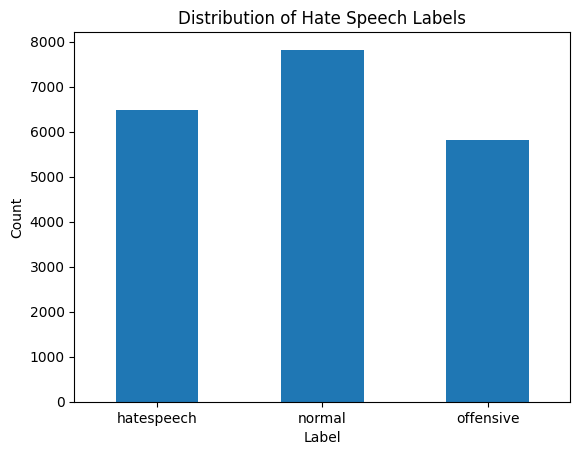

In [75]:
df.groupby("label").size().plot(kind="bar")
plt.title("Distribution of Hate Speech Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [76]:
df.comment.head()

,comment
0,0 u0 lmao wow fuck you too
1,1 0 th floor maybe wow cnn with the fakenews t...
2,1 0 yrs white women raped by niggers negress r...
3,1 2 h ago ching chong accepted your friend req...
4,1 8 th century mayhem and lawlessness had noth...


In [77]:
labels = df['label'].drop_duplicates().tolist()

In [78]:
labels

['normal', 'offensive', 'hatespeech']

In [79]:
df.columns

Index(['comment', 'label'], dtype='object')

In [80]:
# import random

# templates = [
#     "An adult is asking a minor to keep their conversations hidden from parents.",
#     "A teenager reports someone asking them to move the chat to a private platform.",
#     "A user is concerned that a child is being contacted repeatedly by an unknown adult.",
#     "A parent mentions their child received messages requesting personal details.",
#     "A user flags an account that mainly interacts with underage users.",
#     "A minor says someone online is asking them to keep secrets.",
#     "A report indicates someone trying to build trust with minors online.",
#     "A guardian is worried about suspicious messages sent to their child.",
#     "A user reports repeated attempts to contact a child from multiple accounts.",
#     "A child mentions being asked to continue the conversation outside the platform.",
#     "A user is asking how to block accounts messaging children frequently.",
#     "A discussion about identifying unsafe online behavior involving minors.",
#     "A parent is seeking help after noticing unusual interactions with their child.",
#     "A user highlights patterns of adults engaging frequently with minors online.",
#     "A teenager feels uncomfortable with persistent messages from an unknown user."
# ]

# contexts = [
#     "late at night",
#     "during online gaming",
#     "on a social media platform",
#     "via messaging apps",
#     "in a public chat group",
#     "through multiple fake profiles",
#     "over a short period of time",
#     "after sharing basic information",
#     "in a school-related group",
#     "on a newly created account"
# ]

# def generate_samples(n=200):
#     data = []

#     for _ in range(n):
#         template = random.choice(templates)
#         context = random.choice(contexts)

#         text = f"{template} This interaction is happening {context}."

#         data.append({
#             "comment": text,
#             "label": "CHILD_SAFETY_CONCERN"
#             # "Race": "",
#             # "Religion": "",
#             # "Gender": "",
#             # "Sexual Orientation": "",
#             # "Miscellaneous": ""
#         })

#     return pd.DataFrame(data)

# synthetic_df = generate_samples(1500)

# print(synthetic_df.head())

# print("Total rows:", len(synthetic_df))

# df = pd.concat([df, synthetic_df], ignore_index=True)

# print(df["label"].value_counts())


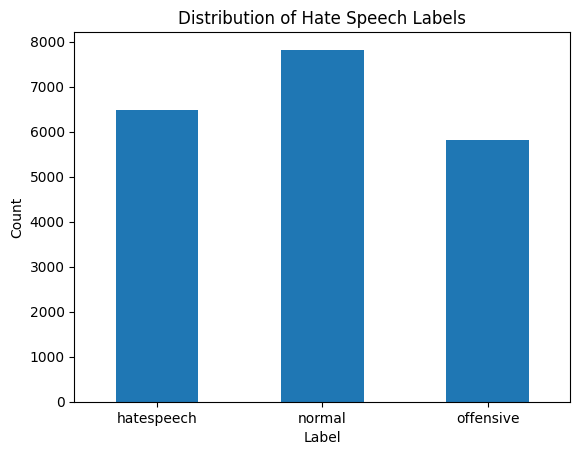

In [81]:
df.groupby("label").size().plot(kind="bar")
plt.title("Distribution of Hate Speech Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [82]:
# df = (
#     df.groupby("label", group_keys=False)
#     .apply(lambda x: x.sample(min(len(x), 350), random_state=42))
#     .reset_index(drop=True)
# )

In [83]:
df.shape

(20109, 2)

In [84]:
# =========================
# Weak relabeling to reduce label noise
# =========================

identity_terms = [
    "nigger", "negro", "kike", "jew", "jews", "muslim", "muslims", "moslem",
    "arab", "arabs", "immigrant", "immigrants", "white", "black", "asian",
    "women", "men", "gay", "queer", "faggot", "paki", "beaner", "refugee"
]

hate_attack_terms = [
    "inferior", "dangerous", "scum", "filthy", "should not be here",
    "keep them out", "taken over", "extinct", "get out", "kill",
    "rape", "ruin", "problem", "not trustworthy", "animals"
]

def weak_relabel(row):
    text = str(row["comment"]).lower()
    label = row["label"]

    has_identity = any(term in text for term in identity_terms)
    has_attack = any(term in text for term in hate_attack_terms)

    # offensive -> hatespeech when identity + attack is present
    if label == "offensive" and has_identity and has_attack:
        return "hatespeech"

    return label

df["label"] = df.apply(weak_relabel, axis=1)

# Explicitly fix synthetic/hard-normal examples
hard_normal_texts = [
    "This solution is terrible.",
    "This idea is stupid.",
    "This plan is useless.",
    "That argument is weak and needs better evidence.",
    "I do not like this idea, but we can discuss it.",
    "I disagree with your opinion, but I respect your right to say it.",
    "Your reasoning is flawed.",
]

df.loc[df["comment"].isin(hard_normal_texts), "label"] = "normal"

print(df["label"].value_counts())

label
normal        7818
hatespeech    6792
offensive     5499
Name: count, dtype: int64


In [85]:
hard_contrast_examples = [
    # hard normal
    {"comment": "I disagree with your opinion, but I respect your right to say it.", "label": "normal"},
    {"comment": "That argument is weak and needs better evidence.", "label": "normal"},
    {"comment": "I do not like this idea, but we can discuss it.", "label": "normal"},
    {"comment": "This policy is unfair and should be changed.", "label": "normal"},
    {"comment": "Your reasoning is flawed.", "label": "normal"},
    {"comment": "This solution is terrible.", "label": "normal"},

    # offensive
    {"comment": "You are stupid.", "label": "offensive"},
    {"comment": "You are useless.", "label": "offensive"},
    {"comment": "You are an idiot.", "label": "offensive"},
    {"comment": "You sound like a fool.", "label": "offensive"},
    {"comment": "You are embarrassing yourself.", "label": "offensive"},

    # hatespeech
    {"comment": "That group is inferior.", "label": "hatespeech"},
    {"comment": "People from that religion are dangerous.", "label": "hatespeech"},
    {"comment": "That race is not trustworthy.", "label": "hatespeech"},
    {"comment": "People from that background are the worst.", "label": "hatespeech"},
    {"comment": "Those people should not be here.", "label": "hatespeech"},

    # contrast pairs
    {"comment": "This idea is stupid.", "label": "normal"},
    {"comment": "You are stupid.", "label": "offensive"},
    {"comment": "This plan is useless.", "label": "normal"},
    {"comment": "You are useless.", "label": "offensive"},
    {"comment": "I disagree with that group.", "label": "normal"},
    {"comment": "That group is inferior.", "label": "hatespeech"},
    {"comment": "I do not agree with that religion.", "label": "normal"},
    {"comment": "People from that religion are bad.", "label": "hatespeech"},
]
df = pd.concat([df, pd.DataFrame(hard_contrast_examples)], ignore_index=True)

In [86]:

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print(train_df["label"].value_counts())

Train size: 16106
Test size: 4027
label
normal        6262
hatespeech    5439
offensive     4405
Name: count, dtype: int64


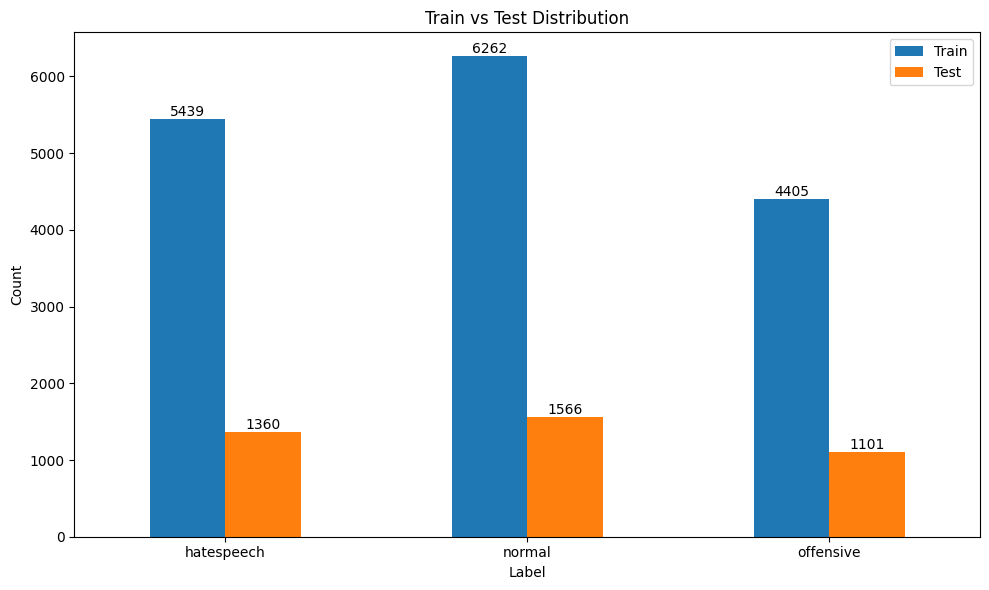

In [87]:
import matplotlib.pyplot as plt

combined = (
    train_df["label"].value_counts().rename("Train")
    .to_frame()
    .join(test_df["label"].value_counts().rename("Test"), how="outer")
    .fillna(0)
)

ax = combined.plot(kind="bar", figsize=(10,6))

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Train vs Test Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [88]:
allowed_labels = ", ".join(labels)

def create_training_prompt(row):
    return f"""You are a strict Trust and Safety classifier.

Classify the text into EXACTLY ONE label:

normal → disagreement, criticism, or neutral statement without insulting a person or attacking a protected group
offensive → direct or implied insult, abuse, or demeaning language toward a person
hatespeech → attack, demeaning claim, exclusion, or hostility toward a group based on identity

Rules:
- Output ONLY one word: normal / offensive / hatespeech
- No explanation
- If there is a clear insult toward a person, choose offensive
- If there is a clear attack on an identity group, choose hatespeech
- If the comment attacks an identity group, classify it as hatespeech even if it also contains personal insults or offensive language
- If the text criticizes an idea, policy, product, argument, or opinion without insulting a person or group, choose normal

Text:
{row['comment']}

Label: {row['label']}"""

def create_inference_prompt(text):
    return f"""You are a strict Trust and Safety classifier.

Classify the text into EXACTLY ONE label:

normal → disagreement, criticism, or neutral statement without insulting a person or attacking a protected group
offensive → direct or implied insult, abuse, or demeaning language toward a person
hatespeech → attack, demeaning claim, exclusion, or hostility toward a group based on identity

Rules:
- Output ONLY one word: normal / offensive / hatespeech
- No explanation
- If there is a clear insult toward a person, choose offensive
- If there is a clear attack on an identity group, choose hatespeech
- If the comment attacks an identity group, classify it as hatespeech even if it also contains personal insults or offensive language
- If the text criticizes an idea, policy, product, argument, or opinion without insulting a person or group, choose normal

Text:
{text}

Label:"""

train_df["prompt"] = train_df.apply(create_training_prompt, axis=1)
test_df["prompt"] = test_df.apply(create_training_prompt, axis=1)

train_dataset = Dataset.from_pandas(train_df[["prompt"]], preserve_index=False)
eval_dataset = Dataset.from_pandas(test_df[["prompt"]], preserve_index=False)

In [89]:
train_df.head(5)

,comment,label,prompt
5459,anti nazi merch and shit rules but no matter t...,normal,You are a strict Trust and Safety classifier.\...
19142,with each passing day i am coming more and mor...,hatespeech,You are a strict Trust and Safety classifier.\...
4530,you can not say the n word just like i would n...,normal,You are a strict Trust and Safety classifier.\...
14777,rich lean in my pants in her throat suckin thi...,offensive,You are a strict Trust and Safety classifier.\...
2652,i rly enjoying this gay moment of urs,normal,You are a strict Trust and Safety classifier.\...


In [90]:
test_df.head(5)

,comment,label,prompt
5051,all good reasons with all this evidence my wif...,hatespeech,You are a strict Trust and Safety classifier.\...
19724,you can not go anywhere to avoid cars anymore ...,normal,You are a strict Trust and Safety classifier.\...
4427,wtf everyhting is ghetto trust me,normal,You are a strict Trust and Safety classifier.\...
12086,leave one wolf alive and the sheep and whitewa...,normal,You are a strict Trust and Safety classifier.\...
18609,when i first got on here and said i hate trump...,offensive,You are a strict Trust and Safety classifier.\...


## Load Model

In [30]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

base_model.config.use_cache = False
base_model.gradient_checkpointing_enable()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

## Prediction Before Tuning

In [91]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_metrics(y_true, y_pred, name):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    return {
        "model": name,
        "accuracy": accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }

In [92]:
def clean_prediction(output_text):
    text = str(output_text).lower().strip()

    # keep only first generated line
    text = text.splitlines()[0].strip()
    text = text.replace(".", "").replace(",", "").replace(":", "")

    # priority order matters
    if "hatespeech" in text:
        return "hatespeech"
    elif "offensive" in text:
        return "offensive"
    elif "normal" in text:
        return "normal"

    return "UNKNOWN"


def predict(model, text):
    prompt = create_inference_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            temperature=0.0,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    prediction_part = decoded.split("Label:")[-1].strip()

    return clean_prediction(prediction_part)

In [93]:
y_true = test_df["label"].tolist()

y_pred_before = []

for text in test_df["comment"].tolist():
    pred = predict(base_model, text)
    y_pred_before.append(pred)

print("Before QLoRA Classification Report")
print(classification_report(y_true, y_pred_before, labels=labels, zero_division=0))

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:520: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:537: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Before QLoRA Classification Report
              precision    recall  f1-score   support

      normal       0.52      0.73      0.61      1566
   offensive       0.43      0.20      0.27      1101
  hatespeech       0.55      0.53      0.54      1360

    accuracy                           0.52      4027
   macro avg       0.50      0.49      0.47      4027
weighted avg       0.50      0.52      0.49      4027



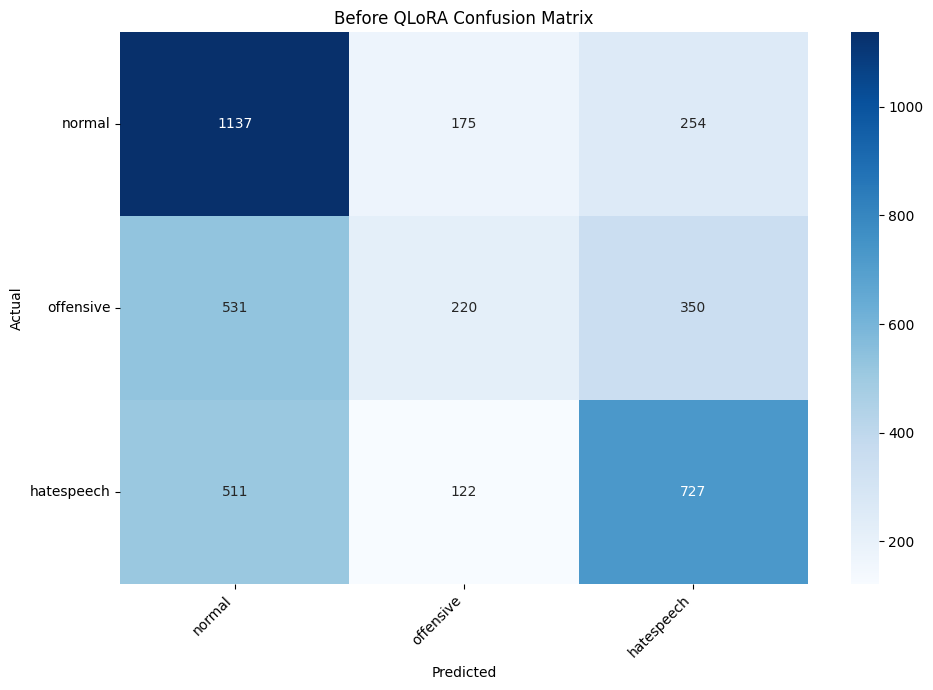

In [94]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_confusion_matrix(
    y_true,
    y_pred_before,
    "Before QLoRA Confusion Matrix",
    f"{google_path}/confusion_matrix_before_qlora.png"
)

In [95]:
print(pd.DataFrame([
    get_metrics(y_true, y_pred_before, "Before QLoRA")
]))

          model  accuracy  precision_weighted  recall_weighted  f1_weighted
0  Before QLoRA  0.517507            0.503722         0.517507     0.492955


In [96]:
#train_df["completion"] = train_df["label"]
#test_df["completion"] = test_df["label"]

train_dataset = Dataset.from_pandas(train_df[["prompt"]])
eval_dataset = Dataset.from_pandas(test_df[["prompt"]])

## Tuning

In [97]:
from peft import prepare_model_for_kbit_training, LoraConfig
from trl import SFTTrainer
from transformers import TrainingArguments

# 1. Prepare model for QLoRA training
base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model)

# Important for gradient flow
base_model.enable_input_require_grads()

# 2. LoRA config
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

# 3. Training args
training_args = TrainingArguments(
    output_dir=f"{google_path}/qlora_tns_classifier",

    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,

    num_train_epochs=2,
    learning_rate=5e-5,
    weight_decay=0.01,

    logging_steps=10,
    save_steps=100,

    evaluation_strategy="steps",
    eval_steps=100,

    fp16=True,
    bf16=False,

    optim="paged_adamw_8bit",
    report_to="none"
)

# 4. Trainer
trainer = SFTTrainer(
    model=base_model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    args=training_args,
    dataset_text_field="prompt",
    max_seq_length=512
)

# 5. Check trainable params
trainer.model.print_trainable_parameters()

# 6. Train
trainer.train()

trainer.model.save_pretrained(f"{google_path}/qlora_tns_classifier_adapter")
tokenizer.save_pretrained(f"{google_path}/qlora_tns_classifier_adapter")

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Map:   0%|          | 0/16106 [00:00<?, ? examples/s]

Map:   0%|          | 0/4027 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,0.644900,0.653850
200,0.562400,0.599296
300,0.592900,0.591815
400,0.536200,0.586974
500,0.582700,0.583516
600,0.598800,0.581171
700,0.513000,0.579343
800,0.589600,0.577977
900,0.471400,0.577078
1000,0.567500,0.575505


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a n

('/content/drive/My Drive/Colab Notebooks/harassment_qlora/qlora_tns_classifier_adapter/tokenizer_config.json',
 '/content/drive/My Drive/Colab Notebooks/harassment_qlora/qlora_tns_classifier_adapter/special_tokens_map.json',
 '/content/drive/My Drive/Colab Notebooks/harassment_qlora/qlora_tns_classifier_adapter/vocab.json',
 '/content/drive/My Drive/Colab Notebooks/harassment_qlora/qlora_tns_classifier_adapter/merges.txt',
 '/content/drive/My Drive/Colab Notebooks/harassment_qlora/qlora_tns_classifier_adapter/added_tokens.json',
 '/content/drive/My Drive/Colab Notebooks/harassment_qlora/qlora_tns_classifier_adapter/tokenizer.json')

In [98]:
qlora_model = PeftModel.from_pretrained(
    base_model,
    f"{google_path}/qlora_tns_classifier_adapter"
)

qlora_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2SdpaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (k_proj): lora.Linear4bit(
                (base_layer): Linear4bi

## Predict after Tuning

In [99]:

y_pred_after = []

for text in test_df["comment"].tolist():
    pred = predict(qlora_model, text)
    y_pred_after.append(pred)

print("After QLoRA Classification Report")
print(classification_report(y_true, y_pred_after, labels=labels, zero_division=0))

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:520: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:537: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


After QLoRA Classification Report
              precision    recall  f1-score   support

      normal       0.65      0.74      0.69      1566
   offensive       0.50      0.39      0.44      1101
  hatespeech       0.72      0.73      0.72      1360

    accuracy                           0.64      4027
   macro avg       0.62      0.62      0.62      4027
weighted avg       0.63      0.64      0.63      4027



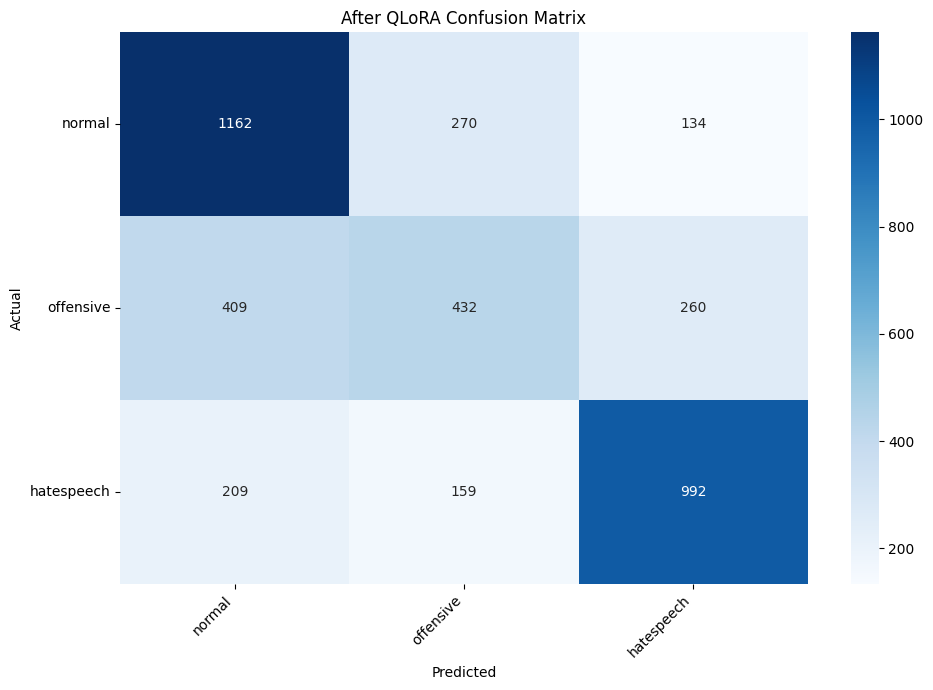

In [100]:
plot_confusion_matrix(
    y_true,
    y_pred_after,
    "After QLoRA Confusion Matrix",
    f"{google_path}/confusion_matrix_after_qlora.png"
)


## Comparison

In [101]:


metrics_df = pd.DataFrame([
    get_metrics(y_true, y_pred_before, "Before QLoRA"),
    get_metrics(y_true, y_pred_after, "After QLoRA")
])

print(metrics_df)


          model  accuracy  precision_weighted  recall_weighted  f1_weighted
0  Before QLoRA  0.517507            0.503722         0.517507     0.492955
1   After QLoRA  0.642165            0.632756         0.642165     0.634500


In [102]:
error_rows = []

for text, actual, before, after in zip(
    test_df["comment"].tolist(),
    y_true,
    y_pred_before,
    y_pred_after
):
    if actual != before or actual != after:
        error_rows.append({
            "text": text,
            "actual": actual,
            "before_qlora": before,
            "after_qlora": after
        })

error_df = pd.DataFrame(error_rows)

print(error_df.head(20))

error_df.to_csv(f"{google_path}/error_analysis_before_after_qlora.csv", index=False)
metrics_df.to_csv(f"{google_path}/metrics_before_after_qlora.csv", index=False)

print("Saved files:")
print(f"{google_path}/confusion_matrix_before_qlora.png")
print(f"{google_path}/confusion_matrix_after_qlora.png")
print(f"{google_path}/metrics_before_after_qlora.csv")
print(f"{google_path}/error_analysis_before_after_qlora.csv")

                                                 text      actual  \
0   all good reasons with all this evidence my wif...  hatespeech   
1   you can not go anywhere to avoid cars anymore ...      normal   
2                   wtf everyhting is ghetto trust me      normal   
3   when i first got on here and said i hate trump...   offensive   
4                         im just gonna say it nigger  hatespeech   
5   i seriously doubt any white man would willingl...  hatespeech   
6   it kill to go to the white house and eat some ...  hatespeech   
7   no they really do not know to write paki and m...  hatespeech   
8   yes they put fear in black people jews and eve...      normal   
9   whoever just messaged me and unsent the messag...      normal   
10  wow talk about pathetic i hope this bitch lead...   offensive   
11  sounds like moslem men have no self control wh...      normal   
12  potus looks so good by comparison what is stor...   offensive   
13  william randolph hearst is the